In [1]:
# ✅ ResNet50 Plant Classifier with Categorical Focal Loss + MixUp (GrowQuest)

import os
import math
import datetime
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import TopKCategoricalAccuracy
from tensorflow_addons.losses import SigmoidFocalCrossEntropy

import tensorflow_probability as tfp


c:\Users\pondt\anaconda3\envs\Fc-env\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\pondt\anaconda3\envs\Fc-env\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.11.0 and strictly below 2.14.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If 

In [2]:
# === DATA SETUP === #
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATASET_DIR = "D:/Senior_WorkTable/GrowQuest_Data_Final"

In [3]:
# ✅ Load Datasets with drop_remainder and class_names fix
def load_datasets():
    # Load training dataset first to capture class names
    raw_train_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, "train"),
        label_mode="categorical",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=42
    )
    class_names = raw_train_ds.class_names  # ✅ Extract before unbatching

    # Apply drop_remainder to training set
    train_ds = raw_train_ds.unbatch().batch(BATCH_SIZE, drop_remainder=True)

    # Load validation dataset
    val_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, "val"),
        label_mode="categorical",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # Load test dataset
    test_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, "test"),
        label_mode="categorical",
        image_size=IMG_SIZE,
        batch_size=1,
        shuffle=False
    )

    return train_ds, val_ds, test_ds, class_names

# ✅ Load and unpack
train_ds, val_ds, test_ds, class_names = load_datasets()

Found 4199 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Found 900 files belonging to 3 classes.


In [4]:
# === Categorical Focal Loss === #
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        loss = alpha * tf.pow(1 - y_pred, gamma) * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return loss_fn

In [5]:
# === MixUp === #
def mixup(ds, alpha=0.2):
    def _mixup(batch1, batch2):
        images1, labels1 = batch1
        images2, labels2 = batch2
        batch_size = tf.shape(images1)[0]

        lam = tfp.distributions.Beta(alpha, alpha).sample([batch_size])
        lam_x = tf.reshape(lam, (batch_size, 1, 1, 1))
        lam_y = tf.reshape(lam, (batch_size, 1))

        mixed_images = lam_x * images1 + (1 - lam_x) * images2
        mixed_labels = lam_y * labels1 + (1 - lam_y) * labels2
        return mixed_images, mixed_labels

    ds1 = ds.shuffle(1024, reshuffle_each_iteration=True)
    ds2 = ds.shuffle(1024, reshuffle_each_iteration=True)
    return tf.data.Dataset.zip((ds1, ds2)).map(_mixup, num_parallel_calls=tf.data.AUTOTUNE)


In [6]:
# === Preprocessing === #
def preprocess(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = train_ds.map(preprocess).cache().shuffle(1000).repeat().prefetch(AUTOTUNE)
train_ds = mixup(train_ds)
val_ds = val_ds.map(preprocess).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess).prefetch(AUTOTUNE)

In [7]:
# === Model Setup === #
def build_resnet50_base(input_shape=(224, 224, 3), trainable=False):
    base_model = ResNet50(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = trainable
    return base_model

def build_custom_classifier(base_model, input_shape=(224, 224, 3), num_classes=3, dropout_rate=0.4):
    inputs = Input(shape=input_shape, name="input_image")
    x = base_model(inputs, training=False)
    x = layers.Conv2D(64, (1, 1), activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

base_model = build_resnet50_base(trainable=False)
model = build_custom_classifier(base_model)

optimizer = Adam(learning_rate=1e-4)
metrics = ['accuracy', TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
loss_fn = categorical_focal_loss(gamma=2.0, alpha=0.25)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics)


In [8]:
# === Callbacks === #
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='checkpoints/best_model_focal_mixup.keras',
                    save_best_only=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

In [9]:
 # === Training === #
steps_per_epoch = math.ceil(4199 / BATCH_SIZE)
validation_steps = math.ceil(900 / BATCH_SIZE)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=70,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)
pd.DataFrame(history.history).to_csv("training_history_focal_mixup.csv", index=False)

Epoch 1/70
131/132 [============================>.] - ETA: 0s - loss: 0.1453 - accuracy: 0.4253 - top_2_accuracy: 0.7254
Epoch 1: val_loss improved from inf to 0.14011, saving model to checkpoints\best_model_focal_mixup.keras
132/132 [==============================] - 28s 66ms/step - loss: 0.1451 - accuracy: 0.4259 - top_2_accuracy: 0.7261 - val_loss: 0.1401 - val_accuracy: 0.3333 - val_top_2_accuracy: 0.7267 - lr: 1.0000e-04
Epoch 2/70
131/132 [============================>.] - ETA: 0s - loss: 0.1218 - accuracy: 0.4933 - top_2_accuracy: 0.7898
Epoch 2: val_loss improved from 0.14011 to 0.12587, saving model to checkpoints\best_model_focal_mixup.keras
132/132 [==============================] - 5s 37ms/step - loss: 0.1216 - accuracy: 0.4941 - top_2_accuracy: 0.7905 - val_loss: 0.1259 - val_accuracy: 0.3711 - val_top_2_accuracy: 0.7911 - lr: 1.0000e-04
Epoch 3/70
131/132 [============================>.] - ETA: 0s - loss: 0.1185 - accuracy: 0.5041 - top_2_accuracy: 0.8099
Epoch 3: val_los

In [10]:
# === Fine-Tuning Phase ===
fine_tune_at = len(base_model.layers) - 80
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

focal_loss = SigmoidFocalCrossEntropy(gamma=2.0, alpha=0.25, reduction='none')

def final_loss(y_true, y_pred):
    return tf.reduce_mean(focal_loss(y_true, y_pred))

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=final_loss,
    metrics=metrics
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=70,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)
pd.DataFrame(fine_tune_history.history).to_csv("fine_tuning_history_focal_mixup.csv", index=False)


Epoch 1/70
131/132 [============================>.] - ETA: 0s - loss: 0.1631 - accuracy: 0.6262 - top_2_accuracy: 0.8879
Epoch 1: val_loss did not improve from 0.08266
132/132 [==============================] - 9s 44ms/step - loss: 0.1632 - accuracy: 0.6255 - top_2_accuracy: 0.8878 - val_loss: 0.1426 - val_accuracy: 0.6800 - val_top_2_accuracy: 0.9044 - lr: 1.0000e-05
Epoch 2/70
131/132 [============================>.] - ETA: 0s - loss: 0.1652 - accuracy: 0.6167 - top_2_accuracy: 0.8822
Epoch 2: val_loss did not improve from 0.08266
132/132 [==============================] - 5s 35ms/step - loss: 0.1651 - accuracy: 0.6177 - top_2_accuracy: 0.8823 - val_loss: 0.1459 - val_accuracy: 0.6500 - val_top_2_accuracy: 0.9178 - lr: 1.0000e-05
Epoch 3/70
132/132 [==============================] - ETA: 0s - loss: 0.1616 - accuracy: 0.6281 - top_2_accuracy: 0.8868
Epoch 3: val_loss did not improve from 0.08266
132/132 [==============================] - 5s 35ms/step - loss: 0.1616 - accuracy: 0.6281 

In [11]:
# Evaluation
results = model.evaluate(test_ds, verbose=1)
for name, value in zip(model.metrics_names, results):
    print(f"✅ {name}: {value:.4f}")

900/900 [==============================] - 12s 13ms/step - loss: 0.1460 - accuracy: 0.6644 - top_2_accuracy: 0.9067
✅ loss: 0.1460
✅ accuracy: 0.6644
✅ top_2_accuracy: 0.9067


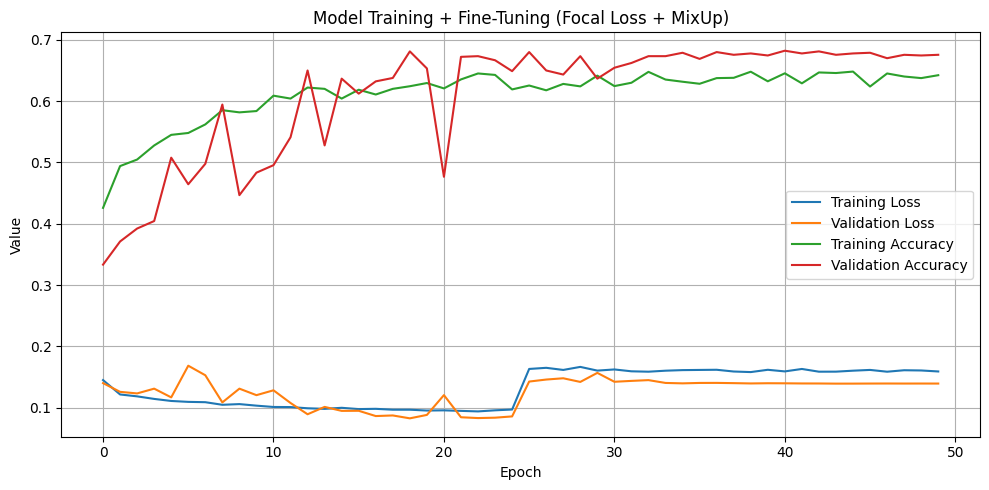

In [12]:
# Plotting
train_history = pd.read_csv("training_history_focal_mixup.csv")
fine_history = pd.read_csv("fine_tuning_history_focal_mixup.csv")
full_history = pd.concat([train_history, fine_history], ignore_index=True)

plt.figure(figsize=(10, 5))
plt.plot(full_history["loss"], label="Training Loss")
plt.plot(full_history["val_loss"], label="Validation Loss")
plt.plot(full_history["accuracy"], label="Training Accuracy")
plt.plot(full_history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Training + Fine-Tuning (Focal Loss + MixUp)")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 21ms/step
              precision    recall  f1-score   support

 Anthracnose       0.64      0.67      0.65       300
Healthy_Leaf       0.70      0.74      0.72       300
 Pest_Damage       0.65      0.58      0.61       300

    accuracy                           0.66       900
   macro avg       0.66      0.66      0.66       900
weighted avg       0.66      0.66      0.66       900



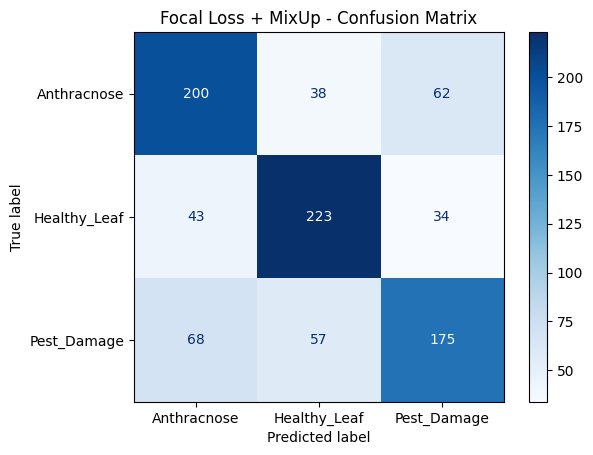

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.append(np.argmax(preds))
    y_true.append(np.argmax(labels.numpy()))

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
plt.title("Focal Loss + MixUp - Confusion Matrix")
plt.show()


In [14]:
model.save("final_resnet_focal_mixup.keras")
